# COVID-19 Case Prediction with Prophet

**Objective**: Forecast daily COVID-19 cases for the next 4 weeks to support healthcare planning.

**Author**: Ibrahim Ahmed Mohammed  
**Course**: DATA610  
**Dataset**: Johns Hopkins University COVID-19 Time Series (Jan 2020 - March 2023) (Updated from the Kaggle Dataset)

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from utils import (
    load_jhu_timeseries, get_available_countries,
    create_intervention_dataframe, get_us_covid_interventions,
    get_country_interventions, summarize_data,
    ProphetWrapper,
    fit_arima, fit_sarima, forecast_arima,
    calculate_rmse, calculate_mae, calculate_smape,
    evaluate_forecast, compare_models,
    plot_forecast, plot_components, plot_intervention_effects,
    plot_model_comparison
)

print("All imports successful!")

2025-12-13 02:59:23 - prophet.plot - ERROR - Importing plotly failed. Interactive plots will not work.


All imports successful!


## 2. Data Preparation

In [2]:
# Load US COVID-19 data from Johns Hopkins
DATA_PATH = '/app/jhu_confirmed_global.csv'

prophet_df = load_jhu_timeseries(DATA_PATH, country='US')

print(f"Dataset shape: {prophet_df.shape}")
print(f"Date range: {prophet_df['ds'].min().date()} to {prophet_df['ds'].max().date()}")
print(f"Total days: {len(prophet_df)}")
prophet_df.head()

2025-12-13 02:59:24 - utils - INFO - Loading JHU time series data for US
2025-12-13 02:59:24 - utils - INFO - Successfully loaded 1143 days of data for US: 2020-01-22 to 2023-03-09


Dataset shape: (1143, 2)
Date range: 2020-01-22 to 2023-03-09
Total days: 1143


,ds,y
0,2020-01-22,0.0
1,2020-01-23,0.0
2,2020-01-24,1.0
3,2020-01-25,0.0
4,2020-01-26,3.0


In [3]:
# Data summary
summary = summarize_data(prophet_df)
print("Data Summary:")
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:,.2f}")
    else:
        print(f"  {key}: {value}")

2025-12-13 02:59:24 - utils - INFO - Generating data summary statistics
2025-12-13 02:59:24 - utils - INFO - Data summary: 1143 observations from 2020-01-22 to 2023-03-09


Data Summary:
  start_date: 2020-01-22 00:00:00
  end_date: 2023-03-09 00:00:00
  n_observations: 1143
  mean: 90,819.39
  std: 126,544.55
  min: 0.00
  max: 1,354,505.00
  missing_values: 0


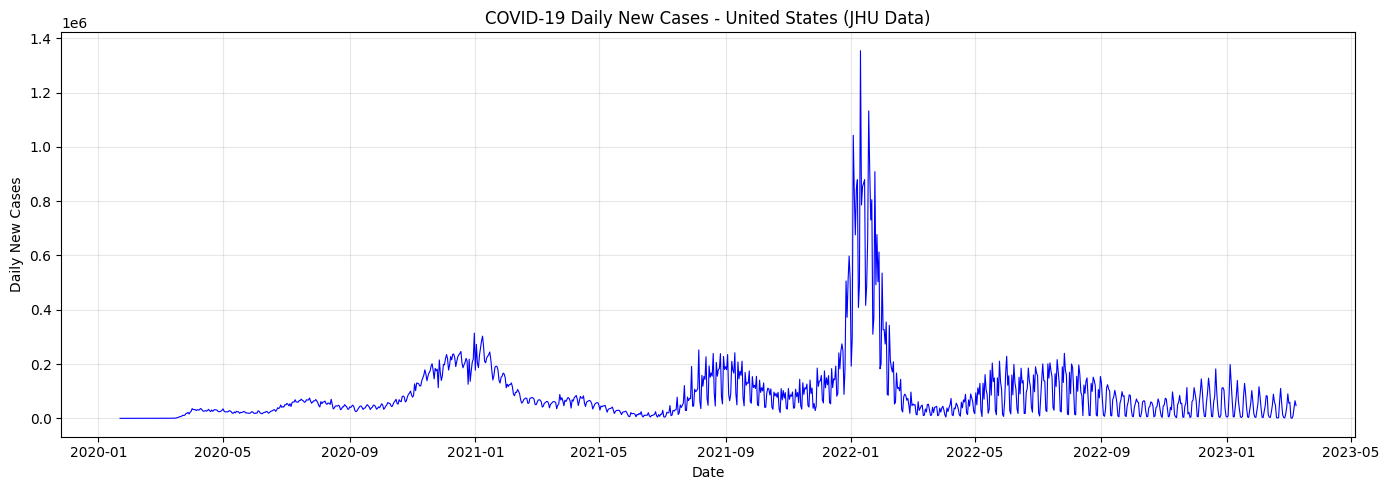

In [4]:
# Visualize raw time series
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df['ds'], prophet_df['y'], 'b-', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Daily New Cases')
ax.set_title('COVID-19 Daily New Cases - United States (JHU Data)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Define Interventions

In [5]:
# Get US intervention dates
interventions = get_us_covid_interventions()
print("US COVID-19 Interventions:")
for name, date in interventions.items():
    print(f"  {name}: {date}")

# Convert to Prophet holidays format
holidays_df = create_intervention_dataframe(interventions)
holidays_df

2025-12-13 02:59:24 - utils - INFO - Creating intervention dataframe with 9 events


US COVID-19 Interventions:
  national_emergency: 2020-03-13
  lockdowns_begin: 2020-03-19
  reopening_phase1: 2020-05-01
  summer_surge: 2020-07-01
  fall_surge: 2020-10-15
  vaccine_auth: 2020-12-11
  vaccine_rollout: 2021-01-15
  delta_surge: 2021-07-01
  omicron_surge: 2021-12-15


,holiday,ds,lower_window,upper_window
0,national_emergency,2020-03-13,0,14
1,lockdowns_begin,2020-03-19,0,14
2,reopening_phase1,2020-05-01,0,14
3,summer_surge,2020-07-01,0,14
4,fall_surge,2020-10-15,0,14
5,vaccine_auth,2020-12-11,0,14
6,vaccine_rollout,2021-01-15,0,14
7,delta_surge,2021-07-01,0,14
8,omicron_surge,2021-12-15,0,14


## 4. Train/Test Split

In [6]:
# Reserve last 28 days for testing
TEST_DAYS = 28
cutoff_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_DAYS)

train = prophet_df[prophet_df['ds'] <= cutoff_date].copy()
test = prophet_df[prophet_df['ds'] > cutoff_date].copy()

print(f"Training: {len(train)} days ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Testing:  {len(test)} days ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training: 1115 days (2020-01-22 to 2023-02-09)
Testing:  28 days (2023-02-10 to 2023-03-09)


## 5. Prophet Model

In [7]:
# Initialize and fit Prophet
prophet_model = ProphetWrapper(
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.1,
    interval_width=0.95
)

prophet_model.set_holidays(holidays_df).fit(train)
print("Prophet model fitted!")

2025-12-13 02:59:25 - utils - INFO - ProphetWrapper initialized with config: {'growth': 'linear', 'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'holidays_prior_scale': 10.0, 'interval_width': 0.95}
2025-12-13 02:59:25 - utils - INFO - Floor constraint: 0.0 (predictions will be non-negative)
2025-12-13 02:59:25 - utils - INFO - Set 9 holidays/interventions
2025-12-13 02:59:25 - utils - INFO - Fitting Prophet model on 1115 observations
2025-12-13 02:59:25 - cmdstanpy - INFO - Chain [1] start processing
2025-12-13 02:59:25 - cmdstanpy - INFO - Chain [1] done processing
2025-12-13 02:59:25 - utils - INFO - Prophet model fitted successfully


Prophet model fitted!


In [8]:
# Generate forecast
forecast = prophet_model.predict(periods=TEST_DAYS + 14, include_history=True)
forecast_test = forecast[forecast['ds'] > cutoff_date].head(TEST_DAYS)
print(f"Forecast for test period:")
forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

2025-12-13 02:59:25 - utils - INFO - Generating 42-period forecast
2025-12-13 02:59:25 - utils - WARNING - Clipping 156 negative predictions to floor=0.0
2025-12-13 02:59:25 - utils - INFO - Forecast generated: 1157 rows (min yhat: 0.00, max yhat: 566532.12)


Forecast for test period:


,ds,yhat,yhat_lower,yhat_upper
1115,2023-02-10,0.0,0.0,53147.771555
1116,2023-02-11,0.0,0.0,0.000000
1117,2023-02-12,0.0,0.0,0.000000
1118,2023-02-13,0.0,0.0,15747.090733
1119,2023-02-14,0.0,0.0,3848.562225


2025-12-13 02:59:25 - utils - INFO - Creating forecast plot
2025-12-13 02:59:25 - utils - INFO - Forecast plot created


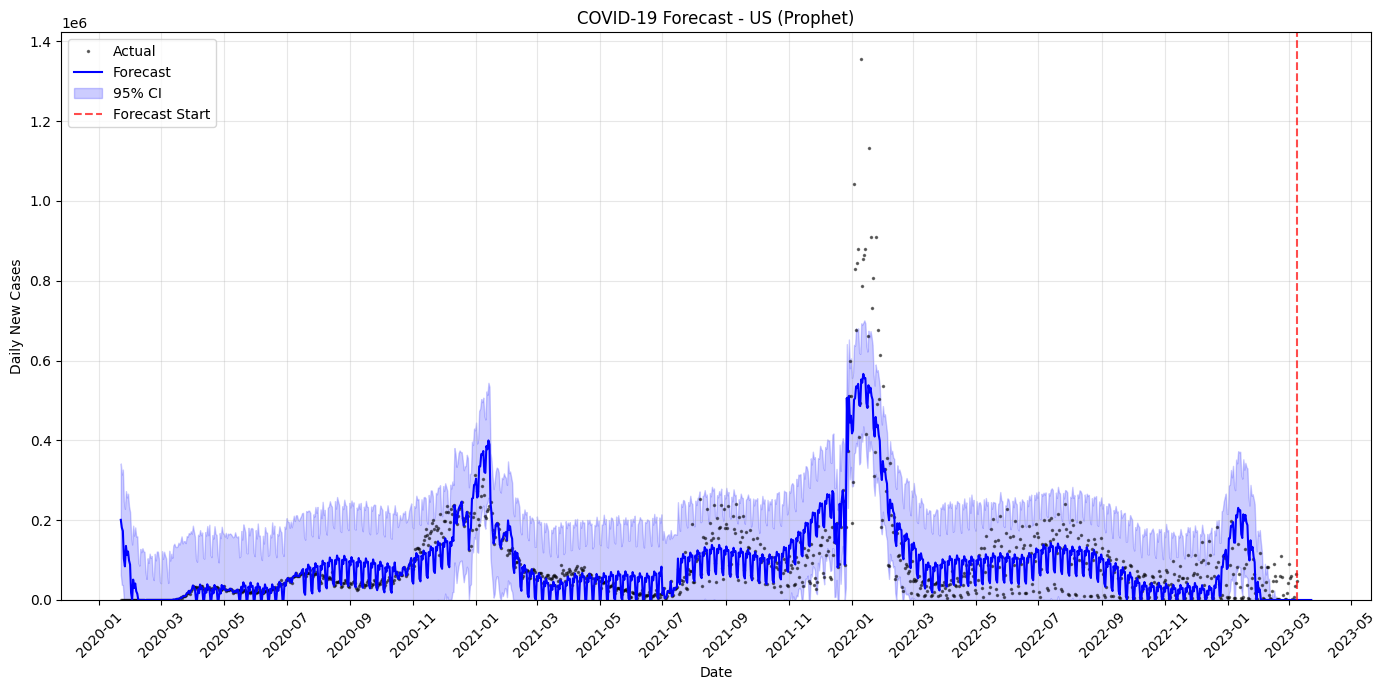

In [9]:
# Plot forecast
fig = plot_forecast(prophet_df, forecast, title='COVID-19 Forecast - US (Prophet)')
plt.show()

2025-12-13 02:59:26 - utils - INFO - Creating component plot
2025-12-13 02:59:26 - utils - INFO - Component plot created


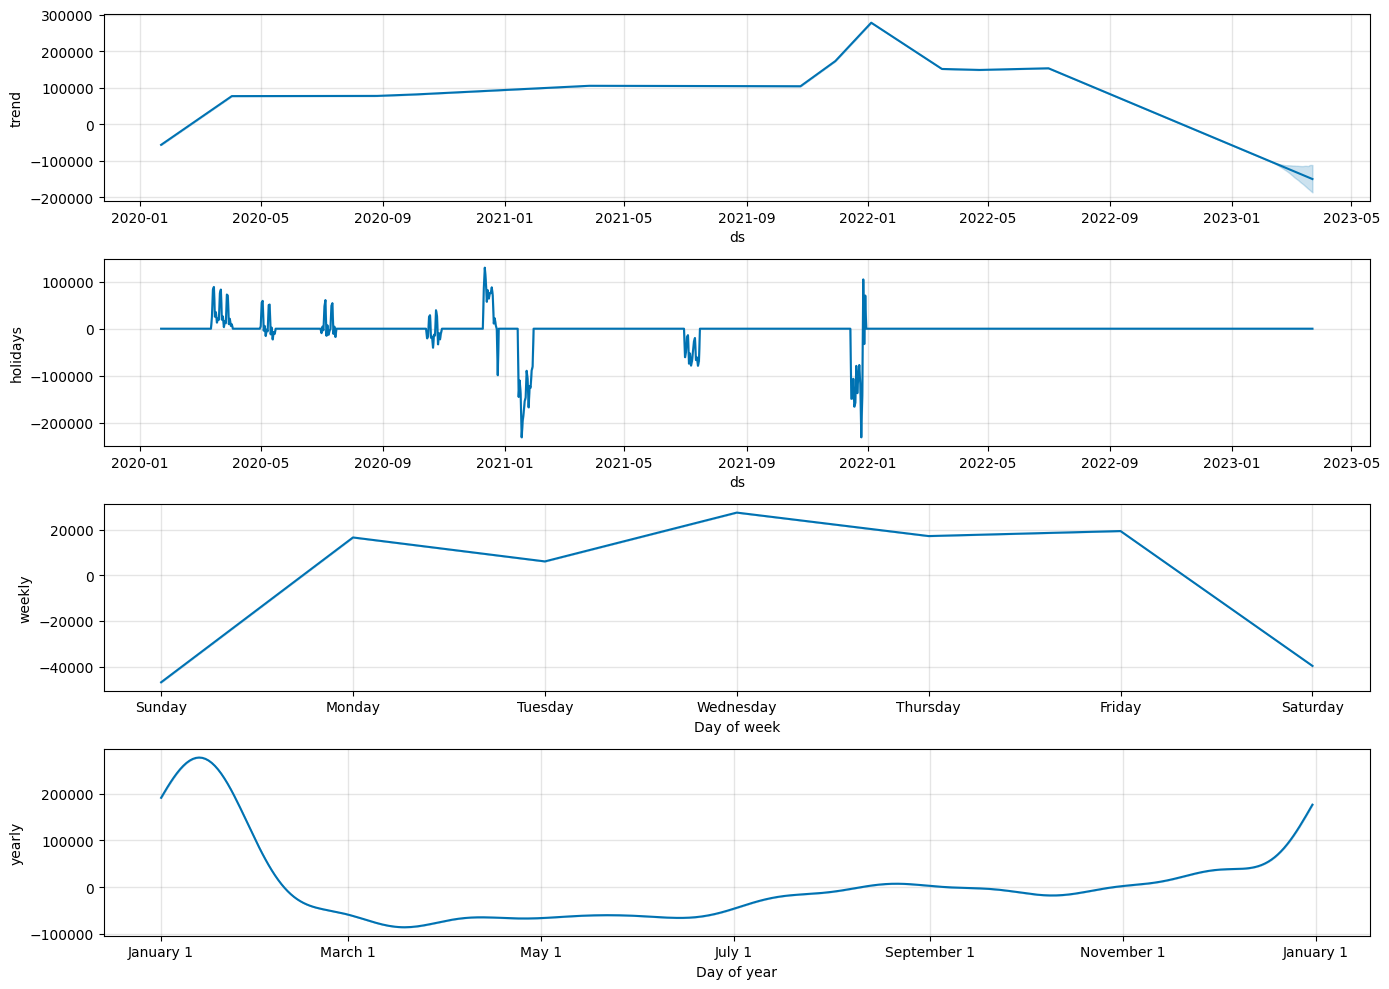

In [10]:
# Plot components
fig = plot_components(prophet_model.model, forecast)
plt.show()

2025-12-13 02:59:26 - utils - INFO - Creating intervention effects plot with 9 interventions
2025-12-13 02:59:26 - utils - INFO - Intervention effects plot created


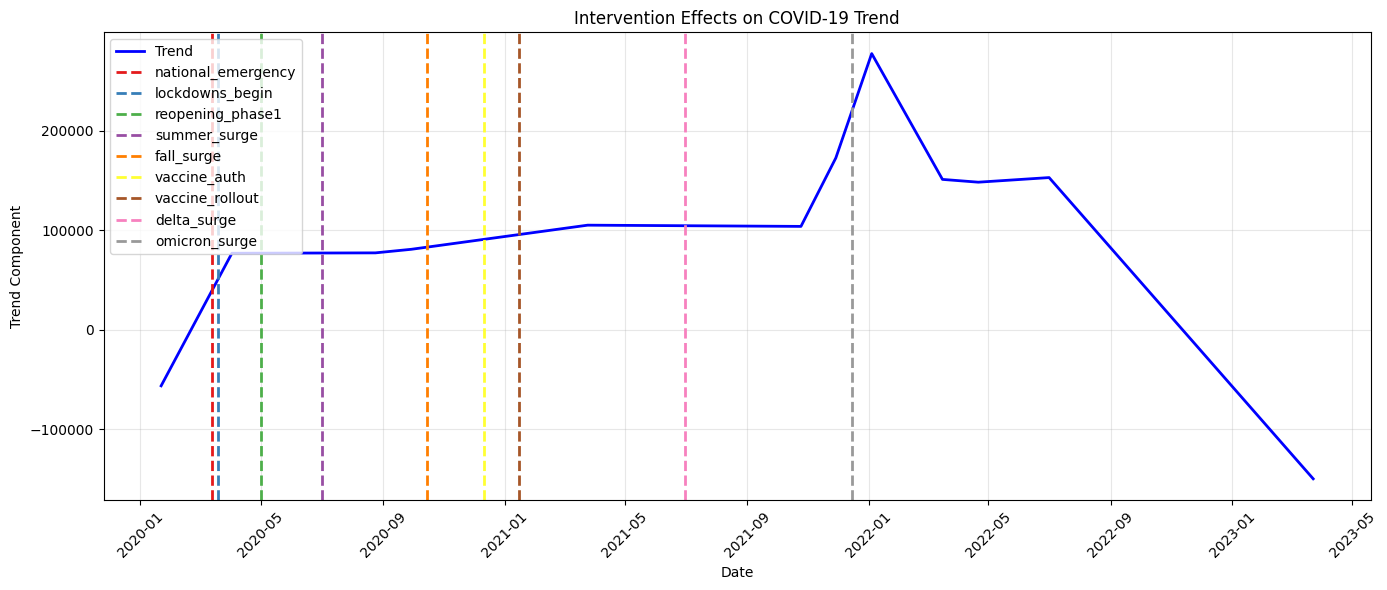

In [11]:
# Plot intervention effects
fig = plot_intervention_effects(forecast, interventions)
plt.show()

## 7. Model Evaluation

In [12]:
# Collect predictions
actual = test['y'].values
prophet_pred = forecast_test['yhat'].values

predictions = {
    'Prophet': prophet_pred
}

# Compare models
comparison = compare_models(actual, predictions)
print("\nModel Comparison:")
print(comparison)

2025-12-13 02:59:26 - utils - INFO - Comparing 1 models
2025-12-13 02:59:26 - utils - INFO - Evaluating Prophet forecast
2025-12-13 02:59:26 - utils - INFO - Prophet metrics: RMSE=46628.15, MAE=34446.54, SMAPE=192.86%
2025-12-13 02:59:26 - utils - INFO - Model comparison complete



Model Comparison:
                 rmse           mae       smape
model                                          
Prophet  46628.147913  34446.535714  192.857143
